### Load and Understand the Dataset

In [1]:
# import required packages
import os
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
data_dir = "/Users/manimaranjb/Music/solar panel"
test_dir = "/Users/manimaranjb/Music/solar panel/test"

In [3]:
print("Main folder exists:", os.path.exists(data_dir))
print("Test folder exists:", os.path.exists(test_dir))

Main folder exists: True
Test folder exists: True


### Define our six classes

In [4]:
classes = [
    "Bird-drop",
    "Clean",
    "Dusty",
    "Electrical-damage",
    "Physical-Damage",
    "Snow-Covered"
]

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 6
Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


### Count image in each classes

In [5]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    class_counts[class_name] = len(images)

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Bird-drop: 191
Clean: 193
Dusty: 190
Electrical-damage: 103
Physical-Damage: 69
Snow-Covered: 123


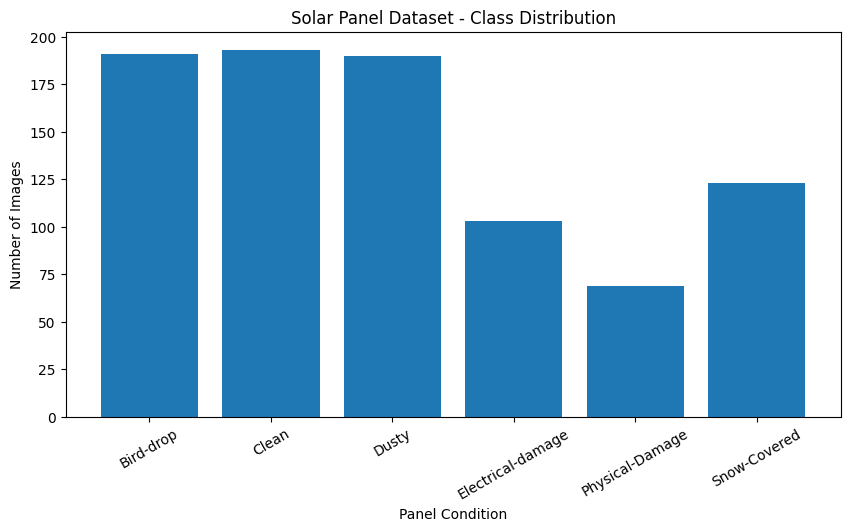

In [6]:
# class distribution
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Solar Panel Dataset - Class Distribution")
plt.xlabel("Panel Condition")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.show()

### Check for corrupted images

In [7]:
corrupted_images = []

for class_name in classes:

    class_path = os.path.join(data_dir, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(image_extensions):

            image_path = os.path.join(
                class_path,
                file_name
            )

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception:
                corrupted_images.append(image_path)

print("Corrupted Images:", len(corrupted_images))

Corrupted Images: 0


### Check original image sizes

In [8]:
image_sizes = []

for class_name in classes:

    class_path = os.path.join(data_dir, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(image_extensions):

            image_path = os.path.join(
                class_path,
                file_name
            )

            try:
                with Image.open(image_path) as img:
                    image_sizes.append(img.size)

            except Exception:
                pass

print("Total Images Checked:", len(image_sizes))
print("Unique Image Sizes:", len(set(image_sizes)))

print("\nSome Image Sizes:")
print(list(set(image_sizes))[:10])

Total Images Checked: 869
Unique Image Sizes: 446

Some Image Sizes:
[(474, 297), (458, 191), (850, 566), (740, 416), (474, 315), (2560, 1707), (602, 348), (622, 415), (750, 1000), (720, 959)]


### Display one sample from each class

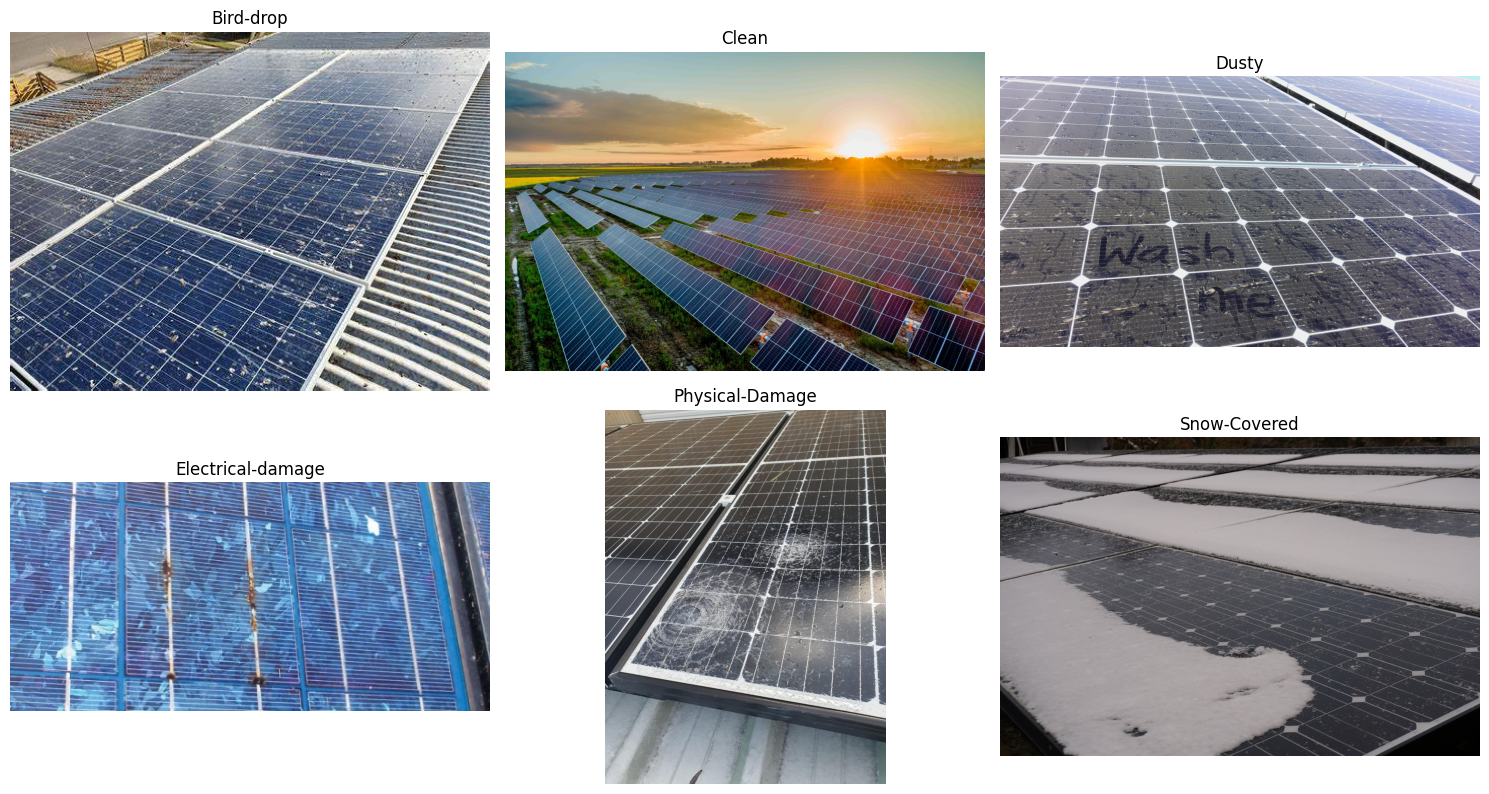

In [9]:
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(data_dir, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    image_path = os.path.join(
        class_path,
        images[0]
    )

    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## EDA :Class distribution

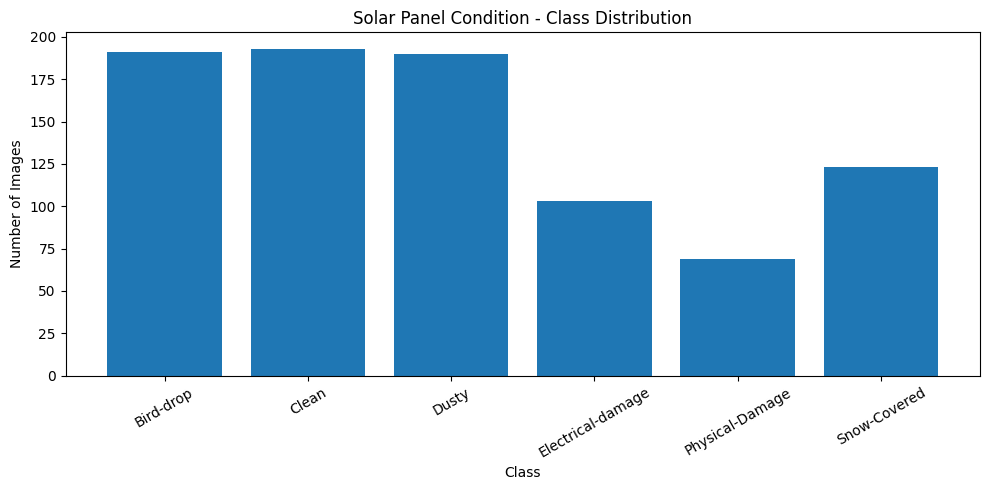

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Solar Panel Condition - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

#### Image Width & Height Distribution

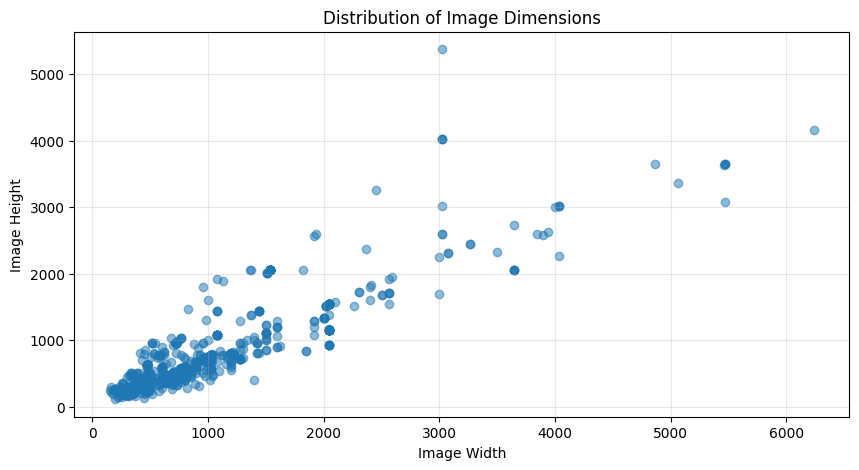

Minimum Width : 149
Maximum Width : 6240
Minimum Height: 110
Maximum Height: 5376


In [13]:
# Image Width & Height Distribution
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

plt.figure(figsize=(10, 5))

plt.scatter(widths, heights, alpha=0.5)

plt.title("Distribution of Image Dimensions")
plt.xlabel("Image Width")
plt.ylabel("Image Height")

plt.grid(alpha=0.3)
plt.show()

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))

THERE IS VERY LARGE VARIATIONS IN IMAGE DIMENSIONS

## Image Preprocessing & Transformations

In [15]:
pip install torch torchvision

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 7.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.5 MB/s eta 0:00:00a 0:00:01
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [torchvision] [torchvision]

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import torch
import torchvision

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

PyTorch Version: 2.14.0
Torchvision Version: 0.29.0


In [17]:
print("MPS Available:", torch.backends.mps.is_available())

MPS Available: True


In [18]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((244, 244)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((244, 244)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
# Test it in one image
sample_path = os.path.join(
    data_dir,
    "Clean",
    os.listdir(os.path.join(data_dir, "Clean"))[0]
)

sample_image = Image.open(sample_path).convert("RGB")

transformed_image = train_transform(sample_image)

print("Original Image Size:", sample_image.size)
print("Transformed Shape:", transformed_image.shape)
print("Tensor Data Type:", transformed_image.dtype)

Original Image Size: (5464, 3640)
Transformed Shape: torch.Size([3, 244, 244])
Tensor Data Type: torch.float32


### Create Train and Validation Datasets

#### Load Dataset with ImageFolder

In [20]:
data_dir = "/Users/manimaranjb/Music/solar panel"

In [21]:
from torchvision.datasets import ImageFolder

In [22]:
dataset = ImageFolder(root=data_dir)

In [23]:
print("Total Images:", len(dataset))
print("Number of Classes:", len(dataset.classes))

print("\nClasses:")
print(dataset.classes)

print("\nClass Mapping:")
print(dataset.class_to_idx)

Total Images: 869
Number of Classes: 6

Classes:
['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']

Class Mapping:
{'Bird-drop': 0, 'Clean': 1, 'Dusty': 2, 'Electrical-damage': 3, 'Physical-Damage': 4, 'Snow-Covered': 5}


In [24]:
from sklearn.model_selection import train_test_split

In [ ]:
indices = list(range(len(dataset)))
labels = dataset.targets

In [26]:
train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

In [27]:
print("Total Images      :", len(dataset))
print("Training Images   :", len(train_indices))
print("Validation Images :", len(val_indices))

Total Images      : 869
Training Images   : 695
Validation Images : 174


In [28]:
# Class distribution after splitting
from collections import Counter

train_labels = [labels[i] for i in train_indices]
val_labels = [labels[i] for i in val_indices]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print("TRAINING CLASS DISTRIBUTION")

for class_index, class_name in enumerate(dataset.classes):
    print(
        f"{class_name}: "
        f"{train_counts[class_index]}"
    )

print("\nVALIDATION CLASS DISTRIBUTION")

for class_index, class_name in enumerate(dataset.classes):
    print(
        f"{class_name}: "
        f"{val_counts[class_index]}"
    )

TRAINING CLASS DISTRIBUTION
Bird-drop: 153
Clean: 154
Dusty: 152
Electrical-damage: 83
Physical-Damage: 55
Snow-Covered: 98

VALIDATION CLASS DISTRIBUTION
Bird-drop: 38
Clean: 39
Dusty: 38
Electrical-damage: 20
Physical-Damage: 14
Snow-Covered: 25


### Apply Separate Training and Validation Transforms

In [31]:
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset

train_full_dataset = ImageFolder(
    root=data_dir,
    transform=train_transform
)

val_full_dataset = ImageFolder(
    root=data_dir,
    transform=val_transform
)

In [32]:
train_dataset = Subset(
    train_full_dataset,
    train_indices
)

val_dataset = Subset(
    val_full_dataset,
    val_indices
)

In [33]:
print("Training Dataset Size   :", len(train_dataset))
print("Validation Dataset Size :", len(val_dataset))

train_image, train_label = train_dataset[0]
val_image, val_label = val_dataset[0]

print("\nTraining Image Shape   :", train_image.shape)
print("Training Label         :", train_label)
print("Training Class         :", dataset.classes[train_label])

print("\nValidation Image Shape :", val_image.shape)
print("Validation Label       :", val_label)
print("Validation Class       :", dataset.classes[val_label])

Training Dataset Size   : 695
Validation Dataset Size : 174

Training Image Shape   : torch.Size([3, 244, 244])
Training Label         : 1
Training Class         : Clean

Validation Image Shape : torch.Size([3, 244, 244])
Validation Label       : 5
Validation Class       : Snow-Covered


### Create PyTorch DataLoaders

In [34]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [35]:
# check number of batches
print("Training Images   :", len(train_dataset))
print("Validation Images :", len(val_dataset))

print("Training Batches  :", len(train_loader))
print("Validation Batches:", len(val_loader))

print("Batch Size        :", batch_size)

Training Images   : 695
Validation Images : 174
Training Batches  : 22
Validation Batches: 6
Batch Size        : 32


In [36]:
# Inspect one training batch
images, labels = next(iter(train_loader))

print("Images Batch Shape:", images.shape)
print("Labels Batch Shape:", labels.shape)

print("\nFirst 10 Labels:")
print(labels[:10])

Images Batch Shape: torch.Size([32, 3, 244, 244])
Labels Batch Shape: torch.Size([32])

First 10 Labels:
tensor([1, 0, 0, 1, 3, 1, 1, 0, 4, 1])


In [37]:
# Check label names
print("First 10 Classes:")

for label in labels[:10]:
    print(dataset.classes[label.item()])

First 10 Classes:
Clean
Bird-drop
Bird-drop
Clean
Electrical-damage
Clean
Clean
Bird-drop
Physical-Damage
Clean


### Calculate Class Weights

In [38]:
import torch
from collections import Counter

# Count training samples in each class
train_class_counts = Counter(train_labels)

total_train = len(train_labels)
num_classes = len(dataset.classes)

class_weights = []

for class_index in range(num_classes):
    count = train_class_counts[class_index]
    
    weight = total_train / (num_classes * count)
    class_weights.append(weight)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class Weights:\n")

for i, class_name in enumerate(dataset.classes):
    print(f"{class_name}: {class_weights[i]:.4f}")

print("\nShape:", class_weights.shape)

Class Weights:

Bird-drop: 0.7571
Clean: 0.7522
Dusty: 0.7621
Electrical-damage: 1.3956
Physical-Damage: 2.1061
Snow-Covered: 1.1820

Shape: torch.Size([6])


## Load Pretrained ResNet18

In [39]:
# Select the device


device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Device:", device)

Device: mps


In [40]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/manimaranjb/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%

Linear(in_features=512, out_features=1000, bias=True)


In [43]:
# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

frozen_params = sum(
    p.numel() for p in model.parameters()
    if not p.requires_grad
)

print("Trainable Parameters:", trainable_params)
print("Frozen Parameters   :", frozen_params)   

Trainable Parameters: 0
Frozen Parameters   : 11689512


### Add Dense + Dropout Classification Head

Pretrained ResNet18
      
      ↓

512 features
      
      ↓

Dense (256)
      
      ↓

ReLU
      
      ↓

Dropout (0.5)
      
      ↓

Dense (6)
      
      ↓

6 Classes

In [44]:
# replace the fully connected layer
import torch.nn as nn

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 6)
)

print(model.fc)

Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=6, bias=True)
)


In [45]:
# Move ResNet18 to MPS
model = model.to(device)

print("Model Device:", next(model.parameters()).device)

Model Device: mps:0


### Check trainable parameters

In [46]:
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

frozen_params = sum(
    p.numel() for p in model.parameters()
    if not p.requires_grad
)

print("Trainable Parameters:", trainable_params)
print("Frozen Parameters   :", frozen_params)

Trainable Parameters: 132870
Frozen Parameters   : 11176512


In [47]:
# Verify exactly which parameters are trainable
print("\nTrainable Layers:")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)


Trainable Layers:
fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


## Loss Function + Optimizer

Loss function → measures how wrong the predictions are.

Optimizer → updates the trainable parameters to reduce that loss.

In [48]:
class_weights = class_weights.to(device)

In [49]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

### Adam optimizer

In [50]:
import torch.optim as optim

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

#### Verify everything


In [52]:
print("Loss Function:")
print(criterion)

print("\nOptimizer:")
print(optimizer)

print("\nLearning Rate:")
print(optimizer.param_groups[0]["lr"])

Loss Function:
CrossEntropyLoss()

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

Learning Rate:
0.001


In [53]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input Batch Shape :", images.shape)
print("Labels Shape      :", labels.shape)
print("Model Output Shape:", outputs.shape)

Input Batch Shape : torch.Size([32, 3, 244, 244])
Labels Shape      : torch.Size([32])
Model Output Shape: torch.Size([32, 6])


In [54]:
### Train and Validate ResNet18

num_epochs = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # TRAINING 
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)

    train_accuracy = (
        100 * correct_train / total_train
    )


    # VALIDATION 
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)

    val_accuracy = (
        100 * correct_val / total_val
    )


    # STORE RESULTS 
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    #  PRINT RESULTS 
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] | Train Loss: 1.6772 | Train Acc: 31.51% | Val Loss: 1.3736 | Val Acc: 59.77%
Epoch [2/10] | Train Loss: 1.2419 | Train Acc: 54.82% | Val Loss: 0.9955 | Val Acc: 72.99%
Epoch [3/10] | Train Loss: 0.9784 | Train Acc: 67.19% | Val Loss: 0.8585 | Val Acc: 72.41%
Epoch [4/10] | Train Loss: 0.8850 | Train Acc: 67.05% | Val Loss: 0.7497 | Val Acc: 76.44%
Epoch [5/10] | Train Loss: 0.7676 | Train Acc: 71.65% | Val Loss: 0.7418 | Val Acc: 77.01%
Epoch [6/10] | Train Loss: 0.7350 | Train Acc: 72.81% | Val Loss: 0.7295 | Val Acc: 76.44%
Epoch [7/10] | Train Loss: 0.7145 | Train Acc: 74.24% | Val Loss: 0.6870 | Val Acc: 76.44%
Epoch [8/10] | Train Loss: 0.6595 | Train Acc: 73.24% | Val Loss: 0.6833 | Val Acc: 77.01%
Epoch [9/10] | Train Loss: 0.6147 | Train Acc: 77.41% | Val Loss: 0.6020 | Val Acc: 81.61%
Epoch [10/10] | Train Loss: 0.5967 | Train Acc: 75.83% | Val Loss: 0.6745 | Val Acc: 77.59%


### Training and Validation Curves

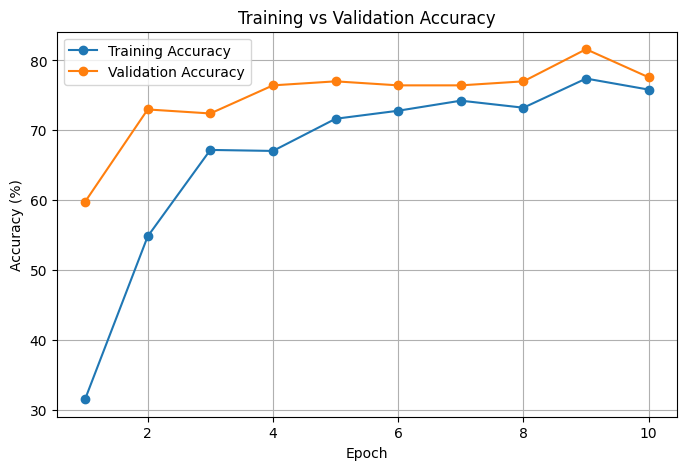

In [55]:
# Accuracy graph

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

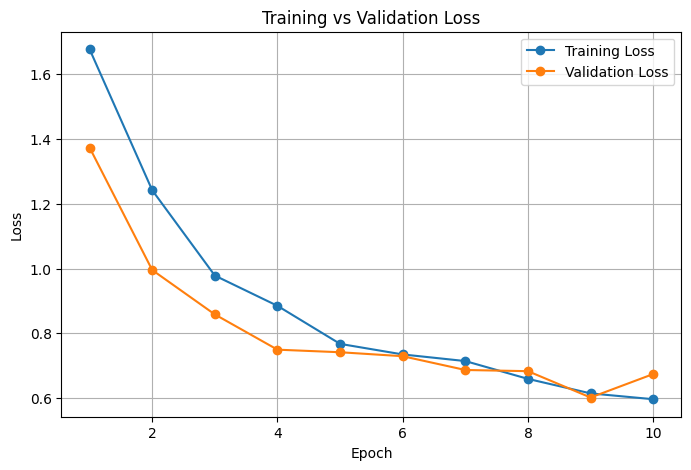

In [56]:
# Loss graph

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [57]:
# Find the best epoch

best_epoch = val_accuracies.index(
    max(val_accuracies)
) + 1

best_val_accuracy = max(val_accuracies)

lowest_val_loss = min(val_losses)

print("Best Epoch              :", best_epoch)
print("Best Validation Accuracy:", f"{best_val_accuracy:.2f}%")
print("Lowest Validation Loss  :", f"{lowest_val_loss:.4f}")

Best Epoch              : 9
Best Validation Accuracy: 81.61%
Lowest Validation Loss  : 0.6020


## Precision, Recall, F1-Score

In [58]:
# Collect predictions

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

print("Actual Labels Collected    :", len(all_labels))
print("Predictions Collected      :", len(all_predictions))

Actual Labels Collected    : 174
Predictions Collected      : 174


### Classification Report

In [59]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes,
    digits=4
)

print(report)

                   precision    recall  f1-score   support

        Bird-drop     0.7895    0.7895    0.7895        38
            Clean     0.6429    0.9231    0.7579        39
            Dusty     0.7931    0.6053    0.6866        38
Electrical-damage     0.9444    0.8500    0.8947        20
  Physical-Damage     0.7333    0.7857    0.7586        14
     Snow-Covered     1.0000    0.7200    0.8372        25

         accuracy                         0.7759       174
        macro avg     0.8172    0.7789    0.7874       174
     weighted avg     0.8009    0.7759    0.7764       174



#### Overall metrics

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Weighted Precision : {precision:.4f}")
print(f"Weighted Recall    : {recall:.4f}")
print(f"Weighted F1-Score  : {f1:.4f}")
print(f"Macro F1-Score     : {macro_f1:.4f}")

Accuracy           : 0.7759
Weighted Precision : 0.8009
Weighted Recall    : 0.7759
Weighted F1-Score  : 0.7764
Macro F1-Score     : 0.7874


#### Confusion Matrix

[[30  5  2  0  1  0]
 [ 0 36  2  1  0  0]
 [ 6  9 23  0  0  0]
 [ 0  2  0 17  1  0]
 [ 2  1  0  0 11  0]
 [ 0  3  2  0  2 18]]


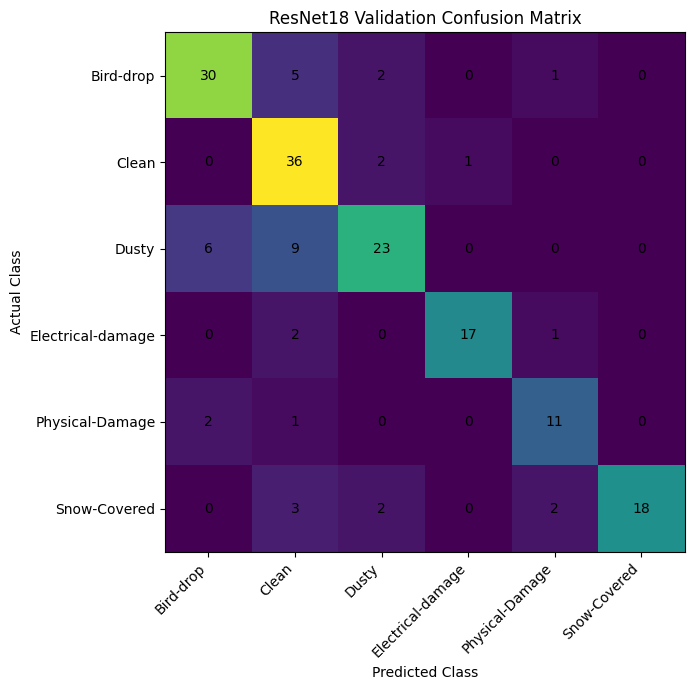

In [62]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(cm)

ax.set_xticks(
    np.arange(len(dataset.classes))
)

ax.set_yticks(
    np.arange(len(dataset.classes))
)

ax.set_xticklabels(
    dataset.classes,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    dataset.classes
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_title(
    "ResNet18 Validation Confusion Matrix"
)

# Display values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

The biggest issue is exactly what the classification report suggested: Dusty. Of 38 actual Dusty images, only 23 were correctly classified; 9 were predicted as Clean and 6 as Bird-drop.

This also explains why Clean has high recall but lower precision: the model is predicting Clean for several images that are actually other conditions.

## Fine-Tune ResNet18

In [63]:
# Unfreeze layer4

for param in model.layer4.parameters():
    param.requires_grad = True

In [64]:
print("Trainable Layers:\n")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable Layers:

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


In [65]:
# Count parameters

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

frozen_params = sum(
    p.numel() for p in model.parameters()
    if not p.requires_grad
)

print("\nTrainable Parameters:", trainable_params)
print("Frozen Parameters   :", frozen_params)



Trainable Parameters: 8526598
Frozen Parameters   : 2782784


In [66]:
# Fine-tuning with a smaller learning rate

import torch.optim as optim

fine_tune_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("Fine-tuning Learning Rate:",
      fine_tune_optimizer.param_groups[0]["lr"])

Fine-tuning Learning Rate: 0.0001


In [67]:
best_val_accuracy = 0.0
best_model_state = None

### Fine-Tuning Training Loop

In [68]:
# Fine-tune for 10 epochs

import copy

fine_tune_epochs = 10

ft_train_losses = []
ft_val_losses = []

ft_train_accuracies = []
ft_val_accuracies = []

best_val_accuracy = 0.0
best_epoch = 0
best_model_state = None


for epoch in range(fine_tune_epochs):

    # ---------------- TRAINING ----------------
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        fine_tune_optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        fine_tune_optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()


    train_loss = running_train_loss / len(train_loader)

    train_accuracy = (
        100 * correct_train / total_train
    )


    # ---------------- VALIDATION ----------------
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()


    val_loss = running_val_loss / len(val_loader)

    val_accuracy = (
        100 * correct_val / total_val
    )


    # ---------------- STORE HISTORY ----------------
    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)

    ft_train_accuracies.append(train_accuracy)
    ft_val_accuracies.append(val_accuracy)


    # ---------------- SAVE BEST MODEL ----------------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )


    # ---------------- PRINT ----------------
    print(
        f"Epoch [{epoch+1}/{fine_tune_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.2f}%"
    )


print("\nBest Fine-Tuning Epoch:", best_epoch)

print(
    "Best Fine-Tuning Validation Accuracy:",
    f"{best_val_accuracy:.2f}%"
)

Epoch [1/10] | Train Loss: 0.5596 | Train Acc: 80.00% | Val Loss: 0.5060 | Val Acc: 83.33%
Epoch [2/10] | Train Loss: 0.3297 | Train Acc: 88.35% | Val Loss: 0.5149 | Val Acc: 83.33%
Epoch [3/10] | Train Loss: 0.1948 | Train Acc: 92.66% | Val Loss: 0.4619 | Val Acc: 86.78%
Epoch [4/10] | Train Loss: 0.1526 | Train Acc: 94.96% | Val Loss: 0.4695 | Val Acc: 87.36%
Epoch [5/10] | Train Loss: 0.1162 | Train Acc: 96.12% | Val Loss: 0.4954 | Val Acc: 86.78%
Epoch [6/10] | Train Loss: 0.0909 | Train Acc: 95.97% | Val Loss: 0.5586 | Val Acc: 86.21%
Epoch [7/10] | Train Loss: 0.0738 | Train Acc: 98.13% | Val Loss: 0.5764 | Val Acc: 85.06%
Epoch [8/10] | Train Loss: 0.0609 | Train Acc: 98.42% | Val Loss: 0.5151 | Val Acc: 87.93%
Epoch [9/10] | Train Loss: 0.0500 | Train Acc: 98.13% | Val Loss: 0.5766 | Val Acc: 86.21%
Epoch [10/10] | Train Loss: 0.0371 | Train Acc: 99.14% | Val Loss: 0.5671 | Val Acc: 87.93%

Best Fine-Tuning Epoch: 8
Best Fine-Tuning Validation Accuracy: 87.93%


## Final evaluation + save best model

In [69]:
model.load_state_dict(best_model_state)
model.eval()

print("Best model restored.")

Best model restored.


In [70]:
# full final evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

final_labels = []
final_predictions = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        final_labels.extend(labels.cpu().numpy())
        final_predictions.extend(predictions.cpu().numpy())

# Metrics
final_accuracy = accuracy_score(
    final_labels,
    final_predictions
)

final_precision = precision_score(
    final_labels,
    final_predictions,
    average="weighted"
)

final_recall = recall_score(
    final_labels,
    final_predictions,
    average="weighted"
)

final_f1 = f1_score(
    final_labels,
    final_predictions,
    average="weighted"
)

final_macro_f1 = f1_score(
    final_labels,
    final_predictions,
    average="macro"
)

print(f"Final Accuracy           : {final_accuracy:.4f}")
print(f"Final Weighted Precision : {final_precision:.4f}")
print(f"Final Weighted Recall    : {final_recall:.4f}")
print(f"Final Weighted F1-Score  : {final_f1:.4f}")
print(f"Final Macro F1-Score     : {final_macro_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        final_labels,
        final_predictions,
        target_names=dataset.classes,
        digits=4
    )
)

print("\nConfusion Matrix:")

final_cm = confusion_matrix(
    final_labels,
    final_predictions
)

print(final_cm)

Final Accuracy           : 0.8793
Final Weighted Precision : 0.8827
Final Weighted Recall    : 0.8793
Final Weighted F1-Score  : 0.8778
Final Macro F1-Score     : 0.8703

Classification Report:

                   precision    recall  f1-score   support

        Bird-drop     0.9231    0.9474    0.9351        38
            Clean     0.8000    0.9231    0.8571        39
            Dusty     0.8571    0.7895    0.8219        38
Electrical-damage     0.8571    0.9000    0.8780        20
  Physical-Damage     0.9000    0.6429    0.7500        14
     Snow-Covered     1.0000    0.9600    0.9796        25

         accuracy                         0.8793       174
        macro avg     0.8896    0.8605    0.8703       174
     weighted avg     0.8827    0.8793    0.8778       174


Confusion Matrix:
[[36  0  1  1  0  0]
 [ 0 36  1  2  0  0]
 [ 2  6 30  0  0  0]
 [ 0  1  0 18  1  0]
 [ 1  1  3  0  9  0]
 [ 0  1  0  0  0 24]]


### Save the final model

In [71]:
model_path = "solarguard_resnet18.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": dataset.classes,
        "image_size": 244
    },
    model_path
)

print("\nModel Saved:", model_path)


Model Saved: solarguard_resnet18.pth


## PROJECT PIPELINE (WORK FLOW)

869 Images

   ↓

Cleaning + EDA

   ↓

Resize 244 × 244

   ↓

Augmentation

   ↓

80/20 Stratified Split

   ↓

Class Weighted Loss

   ↓

Pretrained ResNet18

   ↓

Dense 256

   ↓

ReLU

   ↓

Dropout 0.5

   ↓

Dense 6

   ↓

Transfer Learning

   ↓

Fine-tuning layer4

   ↓

Best Validation Accuracy = 87.93%

   ↓

Final Model

In [72]:
import os

test_dir = "/Users/manimaranjb/Music/test"

print("Test Folder Exists:", os.path.exists(test_dir))

if os.path.exists(test_dir):
    print("\nContents:")
    for item in os.listdir(test_dir):
        print(item)

Test Folder Exists: True

Contents:
8.JPG
9.JPG
14.JPG
15.JPG
16.JPG
12.JPG
13.JPG
11.JPG
10.JPG
4.JPG
5.JPG
7.JPG
6.JPG
2.JPG
3.JPG
1.JPG


#### Predict all 16 images

In [73]:
import os
import torch
from PIL import Image

test_dir = "/Users/manimaranjb/Music/test"

# Use the same preprocessing as validation
test_transform = val_transform

model.eval()

results = []

image_files = sorted(
    [f for f in os.listdir(test_dir)
     if f.lower().endswith((".jpg", ".jpeg", ".png"))],
    key=lambda x: int(os.path.splitext(x)[0])
)

with torch.no_grad():

    for filename in image_files:

        image_path = os.path.join(test_dir, filename)

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Preprocess
        input_tensor = test_transform(image).unsqueeze(0)
        input_tensor = input_tensor.to(device)

        # Prediction
        output = model(input_tensor)

        # Convert logits to probabilities
        probabilities = torch.softmax(output, dim=1)

        confidence, predicted_index = torch.max(
            probabilities, 1
        )

        predicted_class = dataset.classes[
            predicted_index.item()
        ]

        confidence = confidence.item() * 100

        results.append(
            [filename, predicted_class, confidence]
        )

In [74]:
import pandas as pd

test_results_df = pd.DataFrame(
    results,
    columns=[
        "Image",
        "Predicted Condition",
        "Confidence (%)"
    ]
)

test_results_df["Confidence (%)"] = (
    test_results_df["Confidence (%)"].round(2)
)

test_results_df

,Image,Predicted Condition,Confidence (%)
0,1.JPG,Bird-drop,100.00
1,2.JPG,Bird-drop,94.60
2,3.JPG,Bird-drop,99.90
3,4.JPG,Bird-drop,78.16
4,5.JPG,Bird-drop,95.58
5,6.JPG,Clean,84.35
6,7.JPG,Bird-drop,99.87
7,8.JPG,Bird-drop,98.74
8,9.JPG,Bird-drop,95.52
9,10.JPG,Bird-drop,61.53
